# Analisi delle variabili consigliate - Gruppo 3

Slide 10, piste sulle feature: **distanza venditore-cliente, peso e volume, tempo di approvazione del pagamento, categoria, carico del venditore nel periodo.**

Ogni feature e' costruita in `src/features.py` (a grana-ordine) e qui ne guardiamo copertura, segno e forza della relazione col target `delivery_days`.

> Regole seguite: distanza come **media e max** sugli articoli (il target e' l'arrivo dell'ultimo articolo); carico venditore su finestra **strettamente causale** (solo ordini precedenti); per ogni feature si riporta la **copertura (% non-nulli)** perche' la correlazione su un sottoinsieme distorto inganna.

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
import pandas as pd
import matplotlib.pyplot as plt
from src import features
pd.set_option('display.width', 120)

## Tabella feature
`build_feature_table()` = tabella ordine (target + baseline) + le 5 feature consigliate.

In [2]:
t = features.build_feature_table()
print(f'{t.shape[0]:,} ordini x {t.shape[1]} colonne')
t.filter(regex='distance|weight|volume|approval|seller_load|main_category|delivery_days').head()

96,470 ordini x 34 colonne


,delivery_days,distance_km_mean,distance_km_max,total_weight_g,total_volume_cm3,approval_hours,main_category,seller_load_mean,seller_load_max
0,8.436574,18.681711,18.681711,500.0,1976.0,0.178333,housewares,7.0,7
1,13.782037,861.035367,861.035367,400.0,4693.0,30.713889,perfumery,24.0,24
2,9.394213,514.547140,514.547140,420.0,9576.0,0.276111,auto,83.0,83
3,13.208750,1821.802656,1821.802656,450.0,6000.0,0.298056,pet_shop,7.0,7
4,2.873877,29.593095,29.593095,250.0,11475.0,1.030556,stationery,8.0,8


## 1. Copertura e correlazione col target
Spearman (monotona, robusta): quanto ogni feature numerica si muove col target.

In [3]:
y = 'delivery_days'
num = ['distance_km_mean','distance_km_max','total_weight_g','total_volume_cm3',
       'approval_hours','seller_load_mean','seller_load_max']
rows = []
for col in num:
    cov = t[col].notna().mean()*100
    sp = t[[col, y]].dropna().corr(method='spearman').iloc[0, 1]
    rows.append((col, f'{cov:.1f}%', round(sp, 3), round(t[col].median(), 1)))
pd.DataFrame(rows, columns=['feature', 'copertura', 'spearman_r', 'mediana'])

,feature,copertura,spearman_r,mediana
0,distance_km_mean,99.5%,0.543,433.8
1,distance_km_max,99.5%,0.541,435.5
2,total_weight_g,100.0%,0.087,750.0
3,total_volume_cm3,100.0%,0.069,7250.0
4,approval_hours,100.0%,0.088,0.3
5,seller_load_mean,100.0%,0.050,13.0
6,seller_load_max,100.0%,0.048,13.0


## 2. Distanza - controllo qualita'
Il Brasile si estende per ~4300 km: distanze oltre indicano coordinate geolocation sporche (problema noto del dataset), non un errore di calcolo.

In [4]:
print(t['distance_km_mean'].describe()[['min','50%','max']])
bad = (t['distance_km_max'] > 4300).sum()
print(f'\nordini con distanza > 4300 km: {bad}  ({bad/t["distance_km_max"].notna().sum()*100:.2f}%)')

min       0.000000
50%     433.833161
max    8677.859564
Name: distance_km_mean, dtype: float64

ordini con distanza > 4300 km: 4  (0.00%)


## 3. Categoria vs consegna
La categoria non ha correlazione: guardiamo la consegna media per categoria.

In [5]:
g = t.groupby('main_category')['delivery_days'].agg(['mean','count'])
g = g[g['count'] >= 300].sort_values('mean')
print('Piu veloci:'); print(g.head(5).round(1))
print('\nPiu lente:'); print(g.tail(5).round(1))

Piu veloci:
                                 mean  count
main_category                               
food                              9.8    436
construction_tools_construction  10.9    731
luggage_accessories              10.9   1011
small_appliances                 11.0    604
housewares                       11.1   5671

Piu lente:
                       mean  count
main_category                     
garden_tools           13.7   3411
home_confort           13.8    346
consoles_games         13.8   1016
furniture_living_room  14.1    403
office_furniture       20.7   1244


## 4. Carico venditore - controllo causalita'
Il primo ordine di un venditore deve avere carico 0, poi cresce con gli ordini precedenti nella finestra di 30 giorni (nessun ordine futuro).

In [6]:
from src import data_loader
raw = data_loader.load_all_raw()
sv = raw['order_items'][['order_id','seller_id']].drop_duplicates().merge(
    raw['orders'][['order_id','order_purchase_timestamp']], on='order_id')
top = sv['seller_id'].value_counts().index[0]
g = sv[sv.seller_id == top].merge(t[['order_id','seller_load_max']], on='order_id')
g.sort_values('order_purchase_timestamp')[['order_purchase_timestamp','seller_load_max']].head(6)

,order_purchase_timestamp,seller_load_max
796,2017-02-17 07:39:19,0
1480,2017-02-23 10:36:35,1
1228,2017-02-24 20:28:53,2
31,2017-02-27 09:27:13,3
120,2017-02-28 20:57:21,4
1413,2017-03-01 20:28:48,5


## 5. Peso e volume vs consegna
Correlazione monotona debole (~0.07-0.09), ma a fasce (quintili) l'effetto e' coerente: gli ordini piu' pesanti/voluminosi consegnano piu' lentamente. Utile come segnale secondario, soprattutto per un modello ad alberi.

In [7]:
for col in ['total_weight_g', 'total_volume_cm3']:
    fascia = pd.qcut(t[col], q=5, duplicates='drop')
    print(f'{col} per quintile:')
    print(t.groupby(fascia, observed=True)['delivery_days'].agg(['mean', 'median', 'count']).round(1))
    print()

total_weight_g per quintile:
                    mean  median  count
total_weight_g                         
(-0.001, 250.0]     11.7     9.4  20514
(250.0, 500.0]      12.3    10.0  18331
(500.0, 1100.0]     12.4    10.1  19055
(1100.0, 2800.0]    12.8    10.5  19419
(2800.0, 184400.0]  13.7    11.2  19151

total_volume_cm3 per quintile:
                      mean  median  count
total_volume_cm3                         
(-0.001, 2520.0]      11.9     9.7  19487
(2520.0, 4800.0]      12.5    10.1  19123
(4800.0, 10260.0]     12.3    10.1  19294
(10260.0, 24276.0]    12.8    10.4  19273
(24276.0, 1476000.0]  13.4    11.0  19293



## 6. Tempo di approvazione vs consegna
La Spearman e' bassa (~0.09) ma ingannevole: la maggior parte degli ordini viene approvata in meno di un'ora (carta), quindi la variabile e' quasi costante. A fasce emerge il segnale reale: i pagamenti che si approvano tardi (tipico del *boleto* bancario) fanno slittare la consegna di diversi giorni. E' una feature **nota vicino al checkout**, quindi utilizzabile senza leakage.

In [8]:
fascia = pd.cut(t['approval_hours'], bins=[-0.01, 1, 6, 24, 72, 1e9],
                labels=['<1h', '1-6h', '6-24h', '1-3g', '>3g'])
print(t.groupby(fascia, observed=True)['delivery_days'].agg(['mean', 'median', 'count']).round(1))

                mean  median  count
approval_hours                     
<1h             12.1     9.8  61705
1-6h            12.9    10.7   5868
6-24h           12.6    10.3  12010
1-3g            14.1    11.9  14695
>3g             14.9    12.7   2178


## 7. Carico venditore vs consegna
Verificata la causalita' (Sez. 4), guardiamo l'effetto sul target a fasce di carico. La relazione non e' monotona (Spearman ~0.05): profilo quasi piatto con un rialzo solo per i venditori piu' carichi (>30 ordini nella finestra di 30 giorni), dove la coda logistica inizia a pesare.

In [9]:
fascia = pd.cut(t['seller_load_max'], bins=[-0.01, 0, 2, 5, 10, 30, 1e9],
                labels=['0', '1-2', '3-5', '6-10', '11-30', '>30'])
print(t.groupby(fascia, observed=True)['delivery_days'].agg(['mean', 'median', 'count']).round(1))

                 mean  median  count
seller_load_max                     
0                12.7    10.2   6335
1-2              12.2     9.9  11100
3-5              12.2    10.1  12326
6-10             12.1     9.9  14112
11-30            12.3    10.1  24479
>30              13.3    11.0  28118


## Sintesi
Con l'analisi a fasce (che rivela effetti non-lineari nascosti dalla correlazione monotona):
- **Distanza**: driver piu' forte del target (Spearman ~0.54). Media e max quasi identici -> la distanza al venditore piu' lontano coincide spesso con quella media.
- **Categoria**: forte spread (consegna media ~10 vs ~21 giorni tra categorie).
- **Tempo di approvazione**: la feature "debole" piu' interessante. La Spearman e' ~0.09 solo perche' quasi tutti pagano subito (carta); a fasce l'effetto e' netto (~12 gg se approvato <1h vs ~15 gg se >3 giorni, effetto *boleto*). Nota vicino al checkout -> usabile senza leakage.
- **Peso e volume**: effetto debole ma monotono e coerente a quintili (~+2 gg dal quintile piu' leggero al piu' pesante). Segnale secondario.
- **Carico venditore**: relazione non monotona, quasi piatta; conta solo la coda dei venditori molto carichi (>30 ordini/30gg).

**Lettura per il modello:** distanza e categoria portano il grosso del segnale; approvazione, peso/volume e carico venditore sono deboli in forma lineare ma catturabili da un modello ad alberi grazie agli effetti a soglia visti sopra.

**TODO (modellazione):** encoding della categoria, gestione dei nulli di distanza, confronto col baseline `estimated_days`, split temporale prima di consolidare il carico venditore come feature. Motivare le scelte nel README.

## 8. Dataframe completo per il modello
Oltre alle 5 feature di slide (sopra) aggiungiamo le feature **mai guardate finora**:
- feature di calendario dell'acquisto (`purchase_month`, `purchase_dayofweek`, `purchase_is_weekend`), ora costruite in `calendar_features()`;
- gli aggregati a grana-ordine gia' presenti in `order_table` (numero articoli/venditori/prodotti, importi prezzo/spedizione/pagamento, rate, stato del cliente).

Tutte note al checkout (nessun leakage dal target).

In [10]:
t = features.build_feature_table()  # ricostruita: ora include anche le feature di calendario

extra_num = ['n_items', 'n_sellers', 'n_products', 'total_price', 'total_freight',
             'n_payments', 'max_installments', 'total_payment',
             'purchase_month', 'purchase_dayofweek', 'purchase_is_weekend']
extra_cat = ['customer_state']

feature_cols = num + extra_num + ['main_category'] + extra_cat
model_df = t[['order_id', 'purchase_date', y, 'estimated_days'] + feature_cols].copy()

print(f'{model_df.shape[0]:,} ordini x {len(feature_cols)} feature candidate')
print('\nQuota di nulli per colonna (solo se >0):')
na = model_df[feature_cols].isna().mean()
print((na[na > 0] * 100).round(2).astype(str) + '%')

96,470 ordini x 20 feature candidate

Quota di nulli per colonna (solo se >0):
distance_km_mean    0.49%
distance_km_max     0.49%
approval_hours      0.01%
n_payments           0.0%
max_installments     0.0%
total_payment        0.0%
main_category        1.4%
dtype: str


## 9. Feature importance con Random Forest
Split **temporale** (train = primo 80% per data di acquisto, test = ultimo 20%): coerente col TODO della Sintesi, evita di validare su ordini "dal futuro". Le categoriche (`main_category`, `customer_state`) sono codificate come interi — un modello ad alberi non ha bisogno di one-hot; i nulli numerici sono imputati con la mediana calcolata sul solo train.

In [11]:
from sklearn.ensemble import RandomForestRegressor

cat_cols = ['main_category', 'customer_state']
num_cols = [c for c in feature_cols if c not in cat_cols]

df = model_df.sort_values('purchase_date').reset_index(drop=True)
split = int(len(df) * 0.8)
train, test = df.iloc[:split], df.iloc[split:]
print(f'train: {train["purchase_date"].min()} -> {train["purchase_date"].max()}  ({len(train):,} righe)')
print(f'test:  {test["purchase_date"].min()} -> {test["purchase_date"].max()}  ({len(test):,} righe)')

def prep(part, medians=None, cats=None):
    part = part[feature_cols].copy()
    if medians is None:
        medians = part[num_cols].median()
    part[num_cols] = part[num_cols].fillna(medians)
    if cats is None:
        cats = {c: part[c].astype('category').cat.categories for c in cat_cols}
    for c in cat_cols:
        part[c] = pd.Categorical(part[c], categories=cats[c]).codes
    return part, medians, cats

X_train, medians, cats = prep(train)
X_test, _, _ = prep(test, medians, cats)
y_train, y_test = train[y], test[y]

rf = RandomForestRegressor(n_estimators=300, max_depth=12, min_samples_leaf=20,
                            n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)

mae_rf = (rf.predict(X_test) - y_test).abs().mean()
mae_baseline = (test['estimated_days'] - y_test).abs().mean()
print(f'\nR2 test: {rf.score(X_test, y_test):.3f}')
print(f'MAE random forest: {mae_rf:.2f} giorni')
print(f'MAE baseline (estimated_days): {mae_baseline:.2f} giorni')

train: 2016-09-15 -> 2018-05-26  (77,176 righe)
test:  2018-05-26 -> 2018-08-29  (19,294 righe)



R2 test: 0.062
MAE random forest: 4.34 giorni
MAE baseline (estimated_days): 13.13 giorni


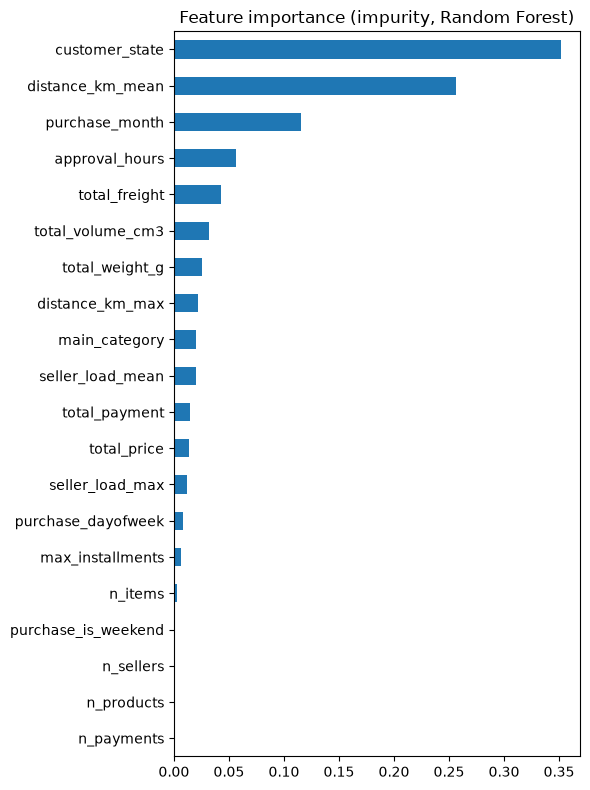

In [12]:
imp = pd.Series(rf.feature_importances_, index=feature_cols).sort_values()
imp.plot.barh(figsize=(6, 8))
plt.title('Feature importance (impurity, Random Forest)')
plt.tight_layout()
plt.show()

L'importance a impurity favorisce le categoriche ad alta cardinalita' (`customer_state`, `main_category` hanno molti livelli e offrono piu' possibili split). Confrontiamo con la **permutation importance**, calcolata sul test set: piu' onesta perche' misura il calo di performance quando si mescola una colonna, indipendentemente dal numero di livelli.

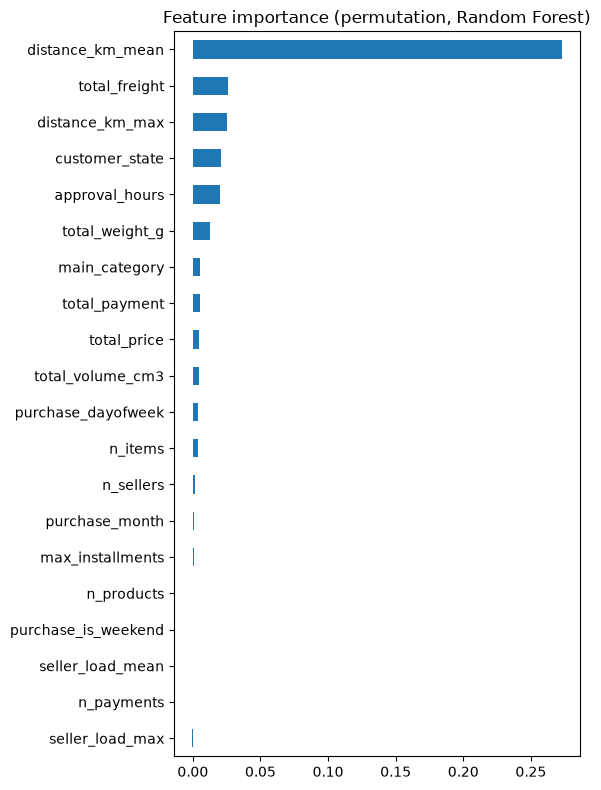

In [13]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(rf, X_test, y_test, n_repeats=5, random_state=42, n_jobs=-1)
imp_perm = pd.Series(perm.importances_mean, index=feature_cols).sort_values()
imp_perm.plot.barh(figsize=(6, 8))
plt.title('Feature importance (permutation, Random Forest)')
plt.tight_layout()
plt.show()

## Sintesi feature importance
Split temporale (train fino a maggio 2018, test sugli ultimi ~3 mesi). Random Forest: R2 test 0.062, MAE 4.34 giorni (contro un MAE di 13.13 giorni se si "prevede" con la sola `estimated_days` sul test: la promessa ufficiale e' tarata per stare cauta, non per essere accurata — un R2 basso non e' quindi in contraddizione col miglioramento di MAE).

- **`distance_km_mean` si conferma il driver dominante**: prima anche in permutation importance (0.27), non solo in impurity. E' l'unica feature dove i due metodi concordano su un peso cosi' alto.
- **`customer_state` e `purchase_month` sono un caso da manuale di importance gonfiata**: altissime in impurity (0.35 e 0.12, prime due) ma quasi irrilevanti in permutation (0.02 e 0.001). L'impurity premia le colonne con tanti livelli/valori distinti (uno stato, un mese) perche' offrono piu' possibili soglie di split, non perche' spiegano davvero il target: **per la selezione delle feature ci si fida della permutation, non dell'impurity**.
- **`total_freight`, `approval_hours`, `total_weight_g`** confermano un contributo secondario ma reale in entrambe le metriche, coerente con l'analisi a fasce delle sezioni precedenti.
- Gli aggregati extra su conteggi/pagamenti (`n_items`, `n_sellers`, `n_products`, `n_payments`, `max_installments`) e il flag weekend pesano pochissimo: candidati alla rimozione per tenere il modello semplice.

**Per il modello:** distanza resta la feature da cui non si puo' prescindere; le categoriche vanno tenute ma valutate con permutation/SHAP, mai con la sola impurity, per non farsi ingannare dalla cardinalita'.